# Setup

In [1]:
%%writefile requirements.txt
transformers==4.44.2
datasets==2.21.0
evaluate==0.4.4
accelerate==0.34.2
optuna==3.6.1
scikit-learn==1.5.0
seaborn==0.13.2
matplotlib==3.9.0
lime==0.2.0.1
scikit-image==0.24.0


Writing requirements.txt


In [2]:
# ── Instala dependências com versões fixadas (não mexe no torch/CUDA já provido pelo
# Kaggle — só fixa os pacotes voláteis instalados via pip) ─────────────────────────────
!pip install -q -r requirements.txt

import os
import time
import json
import numpy as np
import pandas as pd
import torch
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
    set_seed,
)
from datasets import load_dataset
from torchvision.transforms import (
    Compose,
    Resize,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Normalize,
)
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
)

print(f"Torch: {torch.__version__} | CUDA disponível: {torch.cuda.is_available()} | Optuna: {optuna.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Reprodutibilidade e seeds — MESMOS valores usados no mobilenet.ipynb, para que o
# teste de significância estatística consiga parear observações pelo mesmo 'seed'. ──────
SEED = 42
SEEDS_ADICIONAIS = [123, 2024]
set_seed(SEED)

# ── Configuração de dataset — mesma chave/caminho usados no mobilenet.ipynb, para que os
# arquivos de saída fiquem no padrão outputs/{modelo}_{dataset}/ esperado pelas células de
# Tabela Comparativa e Teste de Significância daquele notebook. ────────────────────────
DATASETS = {
    'newdataset': '/kaggle/input/datasets/tiagoudh/newdataset/new_dataset',
    # BRACOL é tratado como já dividido em train/validation/test (assim como o
    # newdataset) -- confira o caminho real no painel Input do Kaggle antes de rodar.
    'bracol': '/kaggle/input/bracol/',
    # RoCoLe não vem pré-dividido em train/validation/test — a célula "Preparação do
    # RoCoLe" logo abaixo faz a divisão automaticamente e grava neste caminho gravável
    # (/kaggle/input é somente leitura) antes do load_dataset ser chamado.
    'rocole': '/kaggle/working/datasets/rocole',
}
DATASET_ATIVO = 'newdataset'

MODELO_NOME  = 'ViT'
NOME_ARQUIVO = f"{MODELO_NOME}_{DATASET_ATIVO}"
OUTPUT_DIR   = os.path.join('outputs', NOME_ARQUIVO)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset ativo: {DATASET_ATIVO}")
print(f"Diretório de saída: {OUTPUT_DIR}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 68.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 84.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 97.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.3 MB/s eta 0:00:00:00:01
ERROR: pi

Preparação do RoCoLe (divisão Train/Validation/Test)

In [ ]:
# O RoCoLe (diferente do newdataset) nao vem pre-dividido em train/validation/test --
# precisa ser separado antes do load_dataset("imagefolder", ...) conseguir detectar os
# splits automaticamente. O HF imagefolder reconhece as pastas pelos nomes "train",
# "validation" e "test" (nao "val") -- por isso o nome da pasta aqui e diferente do usado
# no mobilenet.ipynb (Keras), que usa "val". So roda quando o dataset ativo e o RoCoLe.
if DATASET_ATIVO == 'rocole':
    import pathlib
    import shutil
    from sklearn.model_selection import train_test_split

    def _localizar_raw_dir_rocole():
        """O caminho exato do RoCoLe dentro de /kaggle/input varia conforme como o dataset foi
        anexado -- às vezes os arquivos ficam direto na raiz (/kaggle/input/rocole/), às vezes
        dentro de uma subpasta extra com o nome do dataset (ex.: RoCoLe-dataset). Em vez de
        fixar um único palpite, tenta os candidatos mais prováveis e usa o primeiro que existir
        e contiver pelo menos 2 subpastas (as classes)."""
        import pathlib
        candidatos = [
            pathlib.Path("/kaggle/input/rocole/RoCoLe-dataset"),
            pathlib.Path("/kaggle/input/rocole"),
        ]
        for cand in candidatos:
            if cand.exists() and sum(1 for d in cand.iterdir() if d.is_dir()) >= 2:
                return cand
        raise FileNotFoundError(
            f"Não encontrei a pasta bruta do RoCoLe em nenhum destes caminhos: {candidatos}. "
            "Rode `!find /kaggle/input/rocole -maxdepth 2` numa célula para achar o caminho "
            "real e ajuste ROCOLE_RAW_DIR manualmente."
        )


    ROCOLE_RAW_DIR   = _localizar_raw_dir_rocole()
    ROCOLE_SPLIT_DIR = pathlib.Path(DATASETS['rocole'])                     # /kaggle/input e somente leitura

    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

    if not ROCOLE_SPLIT_DIR.exists():
        classes_rocole = sorted([d.name for d in ROCOLE_RAW_DIR.iterdir() if d.is_dir()])
        print(f"Classes encontradas no RoCoLe: {classes_rocole}")

        for split in ["train", "validation", "test"]:
            for classe in classes_rocole:
                (ROCOLE_SPLIT_DIR / split / classe).mkdir(parents=True, exist_ok=True)

        for classe in classes_rocole:
            arquivos = sorted([
                p for p in (ROCOLE_RAW_DIR / classe).iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ])

            treino, temp = train_test_split(arquivos, train_size=TRAIN_RATIO, random_state=SEED, shuffle=True)
            val_frac_do_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
            val, teste = train_test_split(temp, train_size=val_frac_do_temp, random_state=SEED, shuffle=True)

            for grupo, nome_split in [(treino, "train"), (val, "validation"), (teste, "test")]:
                for arquivo in grupo:
                    shutil.copy2(arquivo, ROCOLE_SPLIT_DIR / nome_split / classe / arquivo.name)

            print(f"  [{classe}] treino={len(treino)} val={len(val)} teste={len(teste)}")

        print(f"RoCoLe dividido salvo em: {ROCOLE_SPLIT_DIR}")
    else:
        print(f"Split do RoCoLe ja existe em {ROCOLE_SPLIT_DIR} -- pulando (apague a pasta se quiser regerar).")
else:
    print(f"Dataset ativo e '{DATASET_ATIVO}' -- nenhuma preparacao de split necessaria (so o RoCoLe precisa).")

Carregando dataset

In [3]:
kaggle_data_path = DATASETS[DATASET_ATIVO]
dataset = load_dataset("imagefolder", data_dir=kaggle_data_path)

print(dataset)

sample_image_for_latency_test = dataset['test'][0]['image']

Resolving data files:   0%|          | 0/1905 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/408 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/409 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1905
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 408
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 409
    })
})


Pré-Processamento com augmentation

In [4]:
# ViT-Small (~22M parâmetros) em vez do ViT-Base original (~86M) — o dataset de treino tem
# só ~1900 imagens, então um transformer menor tende a generalizar igual ou melhor (menos
# risco de overfitting) e já nasce mais leve para mobile, antes mesmo da quantização.
# Para uma versão ainda mais leve, troque por "WinKawaks/vit-tiny-patch16-224" (~5.7M
# parâmetros) — ambos são checkpoints ViT "puros" (compatíveis com ViTForImageClassification;
# variantes DeiT usam uma classe de modelo diferente por causa do token de destilação).
model_checkpoint = "WinKawaks/vit-small-patch16-224"
image_processor = ViTImageProcessor.from_pretrained(model_checkpoint)
norm = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = image_processor.size["height"]

train_transforms = Compose([
    RandomResizedCrop(size, scale=(0.8, 1.0)),
    RandomRotation(degrees=15),
    ColorJitter(brightness=0.2, contrast=0.2),
    RandomHorizontalFlip(),
    ToTensor(),
    norm,
])

# Determinístico (sem RandomResizedCrop) — validação e teste NUNCA devem ter augmentation
# aleatória. O código original da IC aplicava RandomResizedCrop também aqui, o que recortava
# uma região aleatória da folha antes de avaliar (podendo cortar a lesão diagnóstica) e
# tornava accuracy/F1/matriz de confusão dependentes do estado do RNG no momento do .map().
val_transforms = Compose([
    Resize((size, size)),
    ToTensor(),
    norm,
])

def apply_train_transforms(examples):
    examples['pixel_values'] = [train_transforms(img.convert("RGB")) for img in examples['image']]
    return examples

def apply_val_transforms(examples):
    examples['pixel_values'] = [val_transforms(img.convert("RGB")) for img in examples['image']]
    return examples

train_dataset = dataset['train'].map(apply_train_transforms, batched=True)
val_dataset = dataset['validation'].map(apply_val_transforms, batched=True)
test_dataset = dataset['test'].map(apply_val_transforms, batched=True)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Map:   0%|          | 0/1905 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

Busca de Hiperparâmetros (Optuna) + Treinamento Multi-Seed (Rigor Estatístico)

In [5]:
class_names = dataset['train'].features['label'].names
num_labels = len(class_names)

def model_init():
    return ViTForImageClassification.from_pretrained(
        model_checkpoint, num_labels=num_labels,
        id2label={str(i): label for i, label in enumerate(class_names)},
        label2id={label: str(i) for i, label in enumerate(class_names)},
        ignore_mismatched_sizes=True
    )

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


# ── Busca de hiperparâmetros com Optuna (via Trainer.hyperparameter_search) ────────────
# Diferente do mobilenet.ipynb (onde cada trial treina só um classificador leve em cima de
# features congeladas), aqui CADA trial é um fine-tuning real do ViT completo — por isso a
# busca usa poucas épocas e poucos trials, bem menos que o n_trials=60 usado lá. Uma vez
# encontrados os melhores hiperparâmetros, eles são usados no treino final completo (20
# épocas, 3 seeds) na célula seguinte — mesmo padrão "busca barata → treino caro" do
# mobilenet.ipynb.
N_TRIALS_VIT_SEARCH = 10   # reduza se o tempo de GPU do Kaggle for escasso
EPOCAS_BUSCA        = 5

def hp_space_optuna(trial):
    return {
        "learning_rate":                trial.suggest_float("learning_rate", 1e-6, 1e-3, log=True),
        "weight_decay":                 trial.suggest_float("weight_decay", 0.0, 0.3),
        "warmup_ratio":                 trial.suggest_float("warmup_ratio", 0.0, 0.2),
        "per_device_train_batch_size":  trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
    }

def compute_objective_optuna(metrics):
    # Trainer prefixa as métricas de compute_metrics com "eval_" (eval_f1, eval_accuracy, ...)
    return metrics["eval_f1"]

search_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "optuna_search"),
    report_to="none",
    num_train_epochs=EPOCAS_BUSCA,
    per_device_train_batch_size=8,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="no",          # não salva checkpoint por trial — evitaria explosão de disco
    load_best_model_at_end=False,  # incompatível com save_strategy="no"
    seed=SEED,
    disable_tqdm=True,
)

search_trainer = Trainer(
    model_init=model_init,
    args=search_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f"Iniciando busca de hiperparâmetros com Optuna ({N_TRIALS_VIT_SEARCH} trials, {EPOCAS_BUSCA} épocas cada)...")
best_run = search_trainer.hyperparameter_search(
    hp_space=hp_space_optuna,
    compute_objective=compute_objective_optuna,
    n_trials=N_TRIALS_VIT_SEARCH,
    direction="maximize",
    backend="optuna",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

best_params_vit = best_run.hyperparameters
print(f"\nMelhores hiperparâmetros encontrados: {best_params_vit}")
print(f"Melhor F1-Macro (busca, val): {best_run.objective:.4f}")

with open(os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json'), 'w') as f:
    json.dump(best_params_vit, f, indent=2)
print(f"Melhores parâmetros salvos em: {os.path.join(OUTPUT_DIR, f'best_params_{NOME_ARQUIVO}.json')}")

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([5, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2026-07-29 19:02:19,917] A new study created in memory with name: no-name-517d7e9c-6463-4dc8-b2ce-38e56c4cd4f6


Iniciando busca de hiperparâmetros com Optuna (10 trials, 5 épocas cada)...


...

{'eval_loss': 0.3900837302207947, 'eval_accuracy': 0.9705882352941176, 'eval_f1': 0.964917734446531, 'eval_precision': 0.9587314354328873, 'eval_recall': 0.9718315679876885, 'eval_runtime': 33.2693, 'eval_samples_per_second': 12.264, 'eval_steps_per_second': 0.782, 'epoch': 4.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': 0.1716, 'grad_norm': 0.015344217419624329, 'learning_rate': 1.809641583809987e-05, 'epoch': 4.166666666666667}


[I 2026-07-29 21:23:03,185] Trial 9 finished with value: 0.9689346978288265 and parameters: {'learning_rate': 9.717775305059631e-05, 'weight_decay': 0.09351332282682329, 'warmup_ratio': 0.10401360423556216, 'per_device_train_batch_size': 8}. Best is trial 4 with value: 0.97329557278682.


{'eval_loss': 0.38300204277038574, 'eval_accuracy': 0.9730392156862745, 'eval_f1': 0.9689346978288265, 'eval_precision': 0.9632489529440751, 'eval_recall': 0.9754029965591172, 'eval_runtime': 33.4138, 'eval_samples_per_second': 12.211, 'eval_steps_per_second': 0.778, 'epoch': 5.0}
{'train_runtime': 1000.0841, 'train_samples_per_second': 9.524, 'train_steps_per_second': 0.6, 'train_loss': 0.14299884157722922, 'epoch': 5.0}

Melhores hiperparâmetros encontrados: {'learning_rate': 6.847920095574779e-05, 'weight_decay': 0.04184815819561255, 'warmup_ratio': 0.058428929707043636, 'per_device_train_batch_size': 16}
Melhor F1-Macro (busca, val): 0.9733
Melhores parâmetros salvos em: outputs/ViT_newdataset/best_params_ViT_newdataset.json


Treinamento Definitivo Multi-Seed

In [6]:
def treinar_com_seed(seed, best_params):
    """
    Faz o fine-tuning do ViT a partir do checkpoint pré-treinado, usando os melhores
    hiperparâmetros encontrados pelo Optuna (best_params_vit) e uma seed específica.
    Retorna (trainer, training_args, métricas de teste) no MESMO formato de métricas usado
    pelo mobilenet.ipynb (accuracy, f1_macro, precision_macro, recall_macro), para permitir
    a comparação estatística entre os dois notebooks via outputs/*/multiseed_*.csv.
    """
    set_seed(seed)

    training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, f"vit_seed{seed}"),
        report_to="none",
        num_train_epochs=20,
        learning_rate=best_params['learning_rate'],
        per_device_train_batch_size=best_params['per_device_train_batch_size'],
        weight_decay=best_params['weight_decay'],
        warmup_ratio=best_params['warmup_ratio'],
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        seed=seed,
    )

    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        # Encerra o treino se o F1 de validação não melhorar por 3 avaliações seguidas —
        # equivalente ao EarlyStopping(patience=15 em épocas de callback) do mobilenet.ipynb,
        # adaptado à escala de 20 épocas do ViT.
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()

    resultado_teste = trainer.predict(test_dataset)
    y_true_seed = resultado_teste.label_ids
    y_pred_seed = resultado_teste.predictions.argmax(axis=1)
    precision_s, recall_s, f1_s, _ = precision_recall_fscore_support(
        y_true_seed, y_pred_seed, average='macro', zero_division=0
    )
    metricas = {
        'seed':            seed,
        'accuracy':        accuracy_score(y_true_seed, y_pred_seed),
        'f1_macro':        f1_s,
        'precision_macro': precision_s,
        'recall_macro':    recall_s,
    }
    return trainer, training_args, metricas


# Treina com a seed canônica (42) e com as seeds adicionais — os MESMOS valores usados no
# mobilenet.ipynb — para permitir o pareamento por seed no teste de significância
# estatística entre modelos. Atenção: são 3 fine-tunings completos do ViT-base (até 20
# épocas cada, com early stopping), o que pode levar bem mais de 1h no total dependendo da
# GPU do Kaggle.
resultados_multiseed  = []
final_trainer         = None
final_training_args   = None

for seed in [SEED] + SEEDS_ADICIONAIS:
    print(f"\n{'=' * 80}\nTreinando ViT com seed={seed}\n{'=' * 80}")
    trainer_seed, args_seed, metricas_seed = treinar_com_seed(seed, best_params_vit)
    resultados_multiseed.append(metricas_seed)
    print(f"  seed={seed} -> Acurácia={metricas_seed['accuracy']:.4f} | F1-Macro={metricas_seed['f1_macro']:.4f}")

    # Mantém o modelo da seed canônica (42) para as células de matriz de confusão,
    # latência e exportação PyTorch Mobile mais abaixo — as demais são liberadas da GPU
    # explicitamente, já que cada seed é um fine-tuning completo do ViT (ainda dezenas de
    # milhões de parâmetros) e o Kaggle normalmente só tem uma GPU disponível.
    if seed == SEED:
        final_trainer       = trainer_seed
        final_training_args = args_seed
    else:
        del trainer_seed
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df_multiseed = pd.DataFrame(resultados_multiseed)
print("\n── Resultados por seed (ViT) ──")
print(df_multiseed.to_string(index=False))

media_multiseed  = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].mean()
desvio_multiseed = df_multiseed[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']].std()
print(f"\n── Média ± Desvio-padrão ({len(df_multiseed)} seeds) ──")
for col in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    print(f"  {col:17s}: {media_multiseed[col]:.4f} ± {desvio_multiseed[col]:.4f}")

# Persiste no MESMO formato lido pelas células de Tabela Comparativa e Teste de
# Significância Estatística do mobilenet.ipynb (glob por outputs/*/multiseed_*.csv).
df_multiseed_export = df_multiseed.copy()
df_multiseed_export.insert(0, 'dataset', DATASET_ATIVO)
df_multiseed_export.insert(0, 'modelo', MODELO_NOME)
multiseed_path = os.path.join(OUTPUT_DIR, f'multiseed_{NOME_ARQUIVO}.csv')
df_multiseed_export.to_csv(multiseed_path, index=False)
print(f"\nResultados por seed salvos em: {multiseed_path}")
print("Copie a pasta 'outputs/' (ou seu conteúdo) para o mesmo diretório do mobilenet.ipynb "
      "para que o ViT apareça na Tabela Comparativa e no Teste de Significância Estatística.")

# Torna o modelo da seed canônica (42) disponível para as células seguintes deste notebook.
final_trainer.save_model()
image_processor.save_pretrained(final_training_args.output_dir)


Treinando ViT com seed=42


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([5, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.130233,0.955882,0.949662,0.947960,0.951771
2,No log,0.146153,0.960784,0.955296,0.955636,0.955093
3,No log,0.244384,0.953431,0.942192,0.948031,0.941496
4,No log,0.351684,0.958333,0.955188,0.961327,0.950859
5,No log,0.327821,0.980392,0.977878,0.973606,0.982573
6,No log,0.346292,0.973039,0.968158,0.966127,0.970302
7,No log,0.423202,0.965686,0.962620,0.958142,0.968661
8,No log,0.436681,0.960784,0.955180,0.955118,0.955754


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

  seed=42 -> Acurácia=0.9658 | F1-Macro=0.9634

Treinando ViT com seed=123


...

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([5, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.167905,0.938725,0.929420,0.925927,0.934971
2,No log,0.143068,0.968137,0.963577,0.958790,0.969244
3,No log,0.199511,0.965686,0.960186,0.958614,0.962469
4,No log,0.221792,0.970588,0.964432,0.965070,0.965171
5,No log,0.317688,0.975490,0.972650,0.967454,0.979018
6,No log,0.336059,0.973039,0.969604,0.969251,0.970067
7,No log,0.439813,0.968137,0.965092,0.960238,0.971337
8,No log,0.523830,0.960784,0.954684,0.955142,0.954858


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

  seed=2024 -> Acurácia=0.9682 | F1-Macro=0.9655

── Resultados por seed (ViT) ──
 seed  accuracy  f1_macro  precision_macro  recall_macro
   42  0.965770  0.963392         0.963162      0.964122
  123  0.970660  0.968990         0.967874      0.970345
 2024  0.968215  0.965517         0.964340      0.967234

── Média ± Desvio-padrão (3 seeds) ──
  accuracy         : 0.9682 ± 0.0024
  f1_macro         : 0.9660 ± 0.0028
  precision_macro  : 0.9651 ± 0.0025
  recall_macro     : 0.9672 ± 0.0031

Resultados por seed salvos em: outputs/ViT_newdataset/multiseed_ViT_newdataset.csv
Copie a pasta 'outputs/' (ou seu conteúdo) para o mesmo diretório do mobilenet.ipynb para que o ViT apareça na Tabela Comparativa e no Teste de Significância Estatística.


['outputs/ViT_newdataset/vit_seed42/preprocessor_config.json']

Métricas do Modelo Canônico (seed=42)

In [7]:
# As métricas de teste do modelo canônico (seed=42) já foram calculadas na célula de
# treinamento multi-seed acima (resultados_multiseed[0]) — aqui só exibimos o eval_loss
# do HF Trainer como complemento.
test_metrics_hf = final_trainer.evaluate(test_dataset)
print(test_metrics_hf)

metricas_canonicas = resultados_multiseed[0]
print(f"\nModelo canônico (seed={metricas_canonicas['seed']}):")
print(f"  Acurácia        : {metricas_canonicas['accuracy']:.4f}")
print(f"  F1-Macro        : {metricas_canonicas['f1_macro']:.4f}")
print(f"  Precision-Macro : {metricas_canonicas['precision_macro']:.4f}")
print(f"  Recall-Macro    : {metricas_canonicas['recall_macro']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.4784829914569855, 'eval_accuracy': 0.9657701711491442, 'eval_f1': 0.9633917248481627, 'eval_precision': 0.9631624674829228, 'eval_recall': 0.9641224537854705, 'eval_runtime': 34.148, 'eval_samples_per_second': 11.977, 'eval_steps_per_second': 0.761, 'epoch': 8.0}

Modelo canônico (seed=42):
  Acurácia        : 0.9658
  F1-Macro        : 0.9634
  Precision-Macro : 0.9632
  Recall-Macro    : 0.9641


Matriz de Confusão (Modelo Canônico, seed=42)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


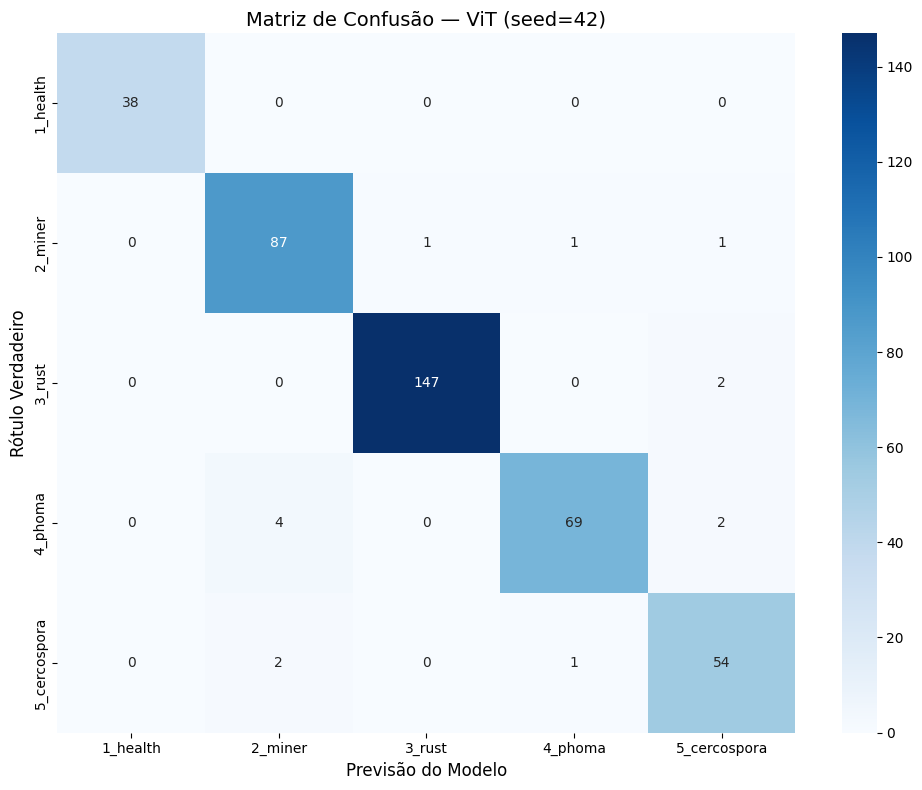

In [8]:
results = final_trainer.predict(test_dataset)
y_true = results.label_ids
y_pred = results.predictions.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Previsão do Modelo", fontsize=12)
plt.ylabel("Rótulo Verdadeiro", fontsize=12)
plt.title("Matriz de Confusão — ViT (seed=42)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'matriz_confusao_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Curvas ROC, Precision-Recall e F1 por Classe (Modelo Canônico, seed=42)

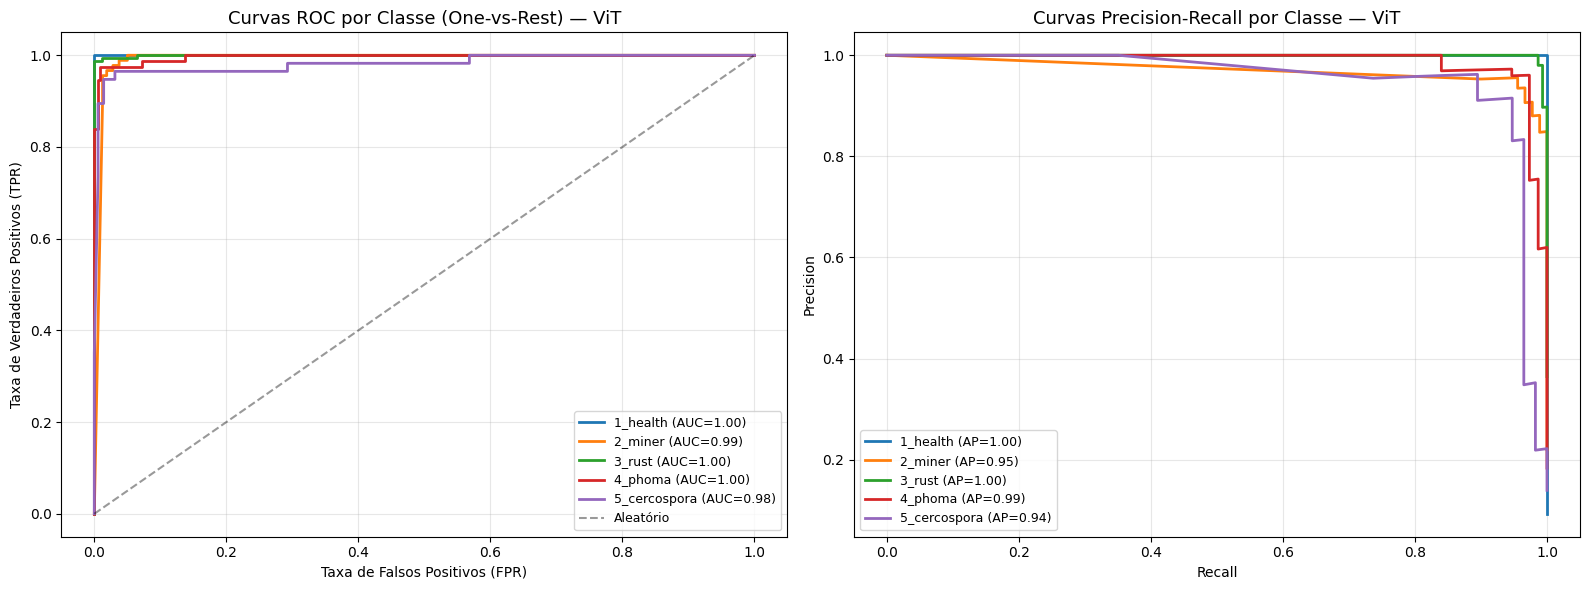

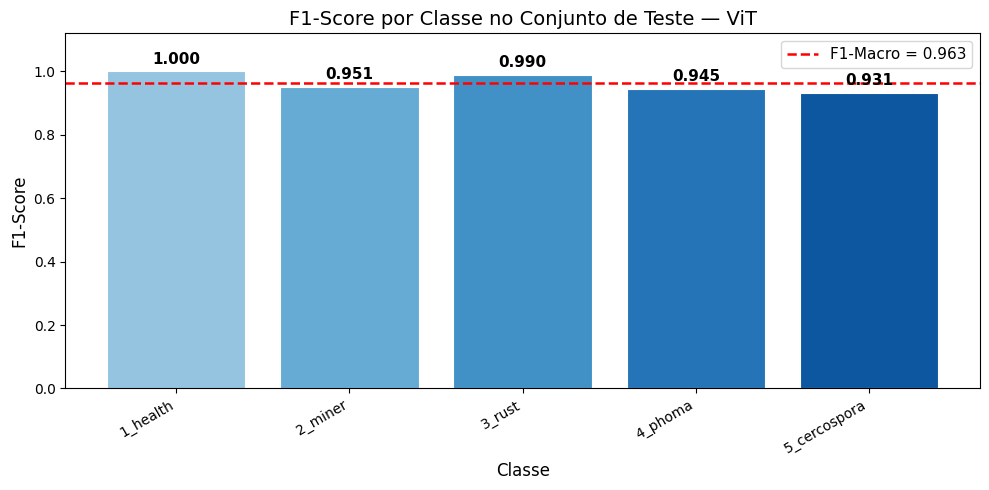

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# results.predictions são logits crus (ViTForImageClassification não aplica softmax) —
# convertidos para probabilidades para as curvas ROC/PR, equivalente ao y_pred_probs_test
# (saída de um softmax no topo do modelo Keras) usado no mobilenet.ipynb.
logits = results.predictions
probs_exp = np.exp(logits - logits.max(axis=1, keepdims=True))
y_pred_probs = probs_exp / probs_exp.sum(axis=1, keepdims=True)

n_classes_vit = len(class_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes_vit)))

# ── Curvas ROC e Precision-Recall ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    axes[1].plot(recall, precision, linewidth=2, label=f'{class_name} (AP={ap:.2f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')
axes[0].set_title('Curvas ROC por Classe (One-vs-Rest) — ViT', fontsize=13)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Curvas Precision-Recall por Classe — ViT', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'curvas_roc_pr_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── F1-Score por Classe (Gráfico de Barras) ────────────────────────────────
f1_por_classe = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)[2]
f1_macro_atual = resultados_multiseed[0]['f1_macro']

plt.figure(figsize=(10, 5))
cores = plt.cm.Blues(np.linspace(0.4, 0.85, n_classes_vit))
bars = plt.bar(class_names, f1_por_classe, color=cores, edgecolor='white', linewidth=0.8)
plt.axhline(y=f1_macro_atual, color='red', linestyle='--', linewidth=1.8, label=f'F1-Macro = {f1_macro_atual:.3f}')

for bar, val in zip(bars, f1_por_classe):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('F1-Score por Classe no Conjunto de Teste — ViT', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.12)
plt.legend(fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'f1_por_classe_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Calibração de Confiança (ECE + Reliability Diagram)

── Calibração de Confiança (Teste) — ViT ──
faixa_confianca  confianca_media  acuracia_media  n_amostras
        0.8-0.9         0.864613        1.000000           2
        0.9-1.0         0.999856        0.965602         407
Expected Calibration Error (ECE): 0.0347  (quanto menor, melhor — 0 é calibração perfeita)


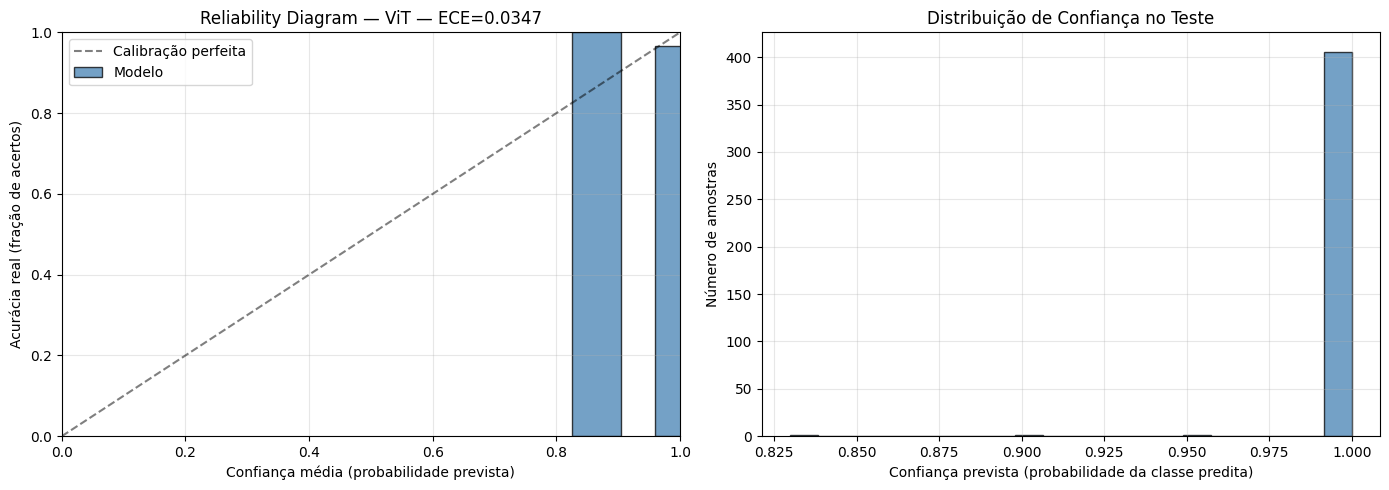

In [10]:
# Mede se a confiança que o modelo reporta reflete de fato a probabilidade real de acerto.
# Um modelo bem calibrado errando ~10% das vezes quando diz "90% de confiança" tem um
# reliability diagram colado na diagonal; se a barra fica sistematicamente ABAIXO da
# diagonal, o modelo é overconfident — problema comum em redes profundas modernas (Guo et
# al., 2017, "On Calibration of Modern Neural Networks"), e Transformers costumam ser ainda
# mais overconfident que CNNs.
def calcular_calibracao(y_true, y_pred, y_pred_probs, n_bins=10):
    confidences = y_pred_probs[np.arange(len(y_pred)), y_pred]
    corretos = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(confidences, bin_edges[1:-1]), 0, n_bins - 1)

    registros = []
    ece = 0.0
    n_total = len(confidences)
    for b in range(n_bins):
        mask = bin_ids == b
        n_bin = int(mask.sum())
        if n_bin == 0:
            continue
        conf_media = float(confidences[mask].mean())
        acc_media = float(corretos[mask].mean())
        peso = n_bin / n_total
        ece += peso * abs(acc_media - conf_media)
        registros.append({
            'faixa_confianca': f'{bin_edges[b]:.1f}-{bin_edges[b + 1]:.1f}',
            'confianca_media': conf_media,
            'acuracia_media':  acc_media,
            'n_amostras':      n_bin,
        })

    return pd.DataFrame(registros), ece


df_calibracao, ece_valor = calcular_calibracao(y_true, y_pred, y_pred_probs)
print("── Calibração de Confiança (Teste) — ViT ──")
print(df_calibracao.to_string(index=False))
print(f"Expected Calibration Error (ECE): {ece_valor:.4f}  (quanto menor, melhor — 0 é calibração perfeita)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability Diagram
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibração perfeita')
axes[0].bar(df_calibracao['confianca_media'], df_calibracao['acuracia_media'],
            width=0.08, alpha=0.75, edgecolor='black', color='steelblue', label='Modelo')
axes[0].set_xlabel('Confiança média (probabilidade prevista)')
axes[0].set_ylabel('Acurácia real (fração de acertos)')
axes[0].set_title(f'Reliability Diagram — ViT — ECE={ece_valor:.4f}', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de confiança
confidences_all = y_pred_probs[np.arange(len(y_pred)), y_pred]
axes[1].hist(confidences_all, bins=20, color='steelblue', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Confiança prevista (probabilidade da classe predita)')
axes[1].set_ylabel('Número de amostras')
axes[1].set_title('Distribuição de Confiança no Teste', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'calibracao_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Correção da Calibração — Temperature Scaling

In [ ]:
# Temperature Scaling (Guo et al., 2017) — a célula anterior mostrou que o modelo é
# overconfident: quase todas as amostras caem na faixa de confiança 90-100%, mas a acurácia
# real ali é menor. Temperature scaling corrige esse viés SEM mudar nenhuma predição (o
# argmax é o mesmo) — só reescala os logits por um único escalar T antes do softmax,
# ajustado no conjunto de VALIDAÇÃO (nunca no teste, para não vazar informação),
# minimizando a log-verossimilhança negativa (NLL).
print("Ajustando temperatura no conjunto de validação...")
val_results = final_trainer.predict(val_dataset)
val_logits = torch.tensor(val_results.predictions, dtype=torch.float32)
val_labels = torch.tensor(val_results.label_ids, dtype=torch.long)

temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
otimizador_temp = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
nll_criterion = torch.nn.CrossEntropyLoss()

def fechamento():
    otimizador_temp.zero_grad()
    loss = nll_criterion(val_logits / temperature, val_labels)
    loss.backward()
    return loss

otimizador_temp.step(fechamento)
T = temperature.item()
print(f"Temperatura ajustada: T = {T:.4f}")

# Aplica a temperatura aos logits do TESTE (nunca vistos durante o ajuste de T)
logits_calibrados = logits / T
probs_exp_cal = np.exp(logits_calibrados - logits_calibrados.max(axis=1, keepdims=True))
y_pred_probs_calibrado = probs_exp_cal / probs_exp_cal.sum(axis=1, keepdims=True)

df_calibracao_pos, ece_pos = calcular_calibracao(y_true, y_pred, y_pred_probs_calibrado)
print("── Calibração APÓS Temperature Scaling (Teste) — ViT ──")
print(df_calibracao_pos.to_string(index=False))
print(f"ECE antes: {ece_valor:.4f}  |  ECE depois: {ece_pos:.4f}")

# ── Comparação visual: antes x depois ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_plot, ece_plot, titulo in [
    (axes[0], df_calibracao, ece_valor, 'Antes (sem calibração)'),
    (axes[1], df_calibracao_pos, ece_pos, f'Depois (T={T:.2f})'),
]:
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibração perfeita')
    ax.bar(df_plot['confianca_media'], df_plot['acuracia_media'],
           width=0.08, alpha=0.75, edgecolor='black', color='steelblue', label='Modelo')
    ax.set_xlabel('Confiança média')
    ax.set_ylabel('Acurácia real')
    ax.set_title(f'{titulo} — ECE={ece_plot:.4f}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'calibracao_temperature_scaling_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("A partir daqui, y_pred_probs_calibrado contém as probabilidades corrigidas — use-as "
      "(em vez de y_pred_probs) na interface do app para exibir uma confiança que reflete "
      "melhor a taxa de acerto real do modelo.")

# Limiar de Abstenção Baseado em Confiança (Predição Seletiva)

In [ ]:
# A calibração mostrou que o modelo é overconfident: mesmo os ~3,4% de erros no teste
# tendem a vir com confiança alta. Uma forma prática de lidar com isso no app é a PREDIÇÃO
# SELETIVA: em vez de sempre mostrar um diagnóstico, o app pode "abster-se" (pedir outra
# foto, ou avisar o produtor que o resultado é incerto) quando a confiança CALIBRADA
# (y_pred_probs_calibrado, da célula de Temperature Scaling) fica abaixo de um limiar.
confidences_cal = y_pred_probs_calibrado[np.arange(len(y_pred)), y_pred]
corretos_bin = (y_pred == y_true)

# ── Curva Risco × Cobertura (Risk-Coverage) ─────────────────────────────────
# Cobertura = fração de amostras que o modelo aceitaria responder (confiança >= limiar).
# Acurácia nas mantidas = qualidade das respostas que o modelo de fato daria.
limiares_curva = np.arange(0.0, 1.001, 0.01)
coberturas, acuracias_mantidas = [], []
for t in limiares_curva:
    mask = confidences_cal >= t
    coberturas.append(mask.mean())
    acuracias_mantidas.append(corretos_bin[mask].mean() if mask.sum() > 0 else np.nan)

plt.figure(figsize=(8, 5))
plt.plot(coberturas, acuracias_mantidas, linewidth=2, color='steelblue')
plt.axhline(y=corretos_bin.mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'Acurácia sem abstenção = {corretos_bin.mean():.3f}')
plt.xlabel('Cobertura (fração de imagens respondidas)')
plt.ylabel('Acurácia nas respostas mantidas')
plt.title('Curva Risco × Cobertura — ViT (confiança calibrada)', fontsize=13)
plt.gca().invert_xaxis()  # cobertura decrescente da esquerda pra direita = limiar crescente
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'risco_cobertura_{NOME_ARQUIVO}.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ── Tabela para limiares candidatos ─────────────────────────────────────────
LIMIARES_CANDIDATOS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
registros_abstencao = []
for t in LIMIARES_CANDIDATOS:
    mask = confidences_cal >= t
    n_mantidas = int(mask.sum())
    n_abstidas = int(len(mask) - n_mantidas)
    acc_mantidas = float(corretos_bin[mask].mean()) if n_mantidas > 0 else None
    erros_evitados = int(((~mask) & (~corretos_bin)).sum())   # erros que ficam de fora (abstidos)
    erros_que_passam = int((mask & (~corretos_bin)).sum())     # erros que o app mostraria mesmo assim
    registros_abstencao.append({
        'limiar':                  t,
        'cobertura (%)':           round(100 * n_mantidas / len(mask), 1),
        'acurácia nas mantidas':   round(acc_mantidas, 4) if acc_mantidas is not None else None,
        'n_abstidas':              n_abstidas,
        'erros_evitados':          erros_evitados,
        'erros_que_ainda_passam':  erros_que_passam,
    })

df_abstencao = pd.DataFrame(registros_abstencao)
print("── Predição Seletiva — Cobertura × Acurácia por limiar de confiança ──")
print(df_abstencao.to_string(index=False))

abstencao_path = os.path.join(OUTPUT_DIR, f'abstencao_{NOME_ARQUIVO}.csv')
df_abstencao.to_csv(abstencao_path, index=False)
print(f"Resultados salvos em: {abstencao_path}")
print("Escolha o limiar considerando o trade-off do seu caso de uso: limiares mais altos "
      "abstêm mais (o produtor precisa tirar outra foto com mais frequência), mas evitam "
      "mais diagnósticos errados mostrados com falsa confiança.")

# XAI — Attention Rollout (equivalente ao Grad-CAM para Vision Transformers)

Gerando explicações via Attention Rollout por classe...


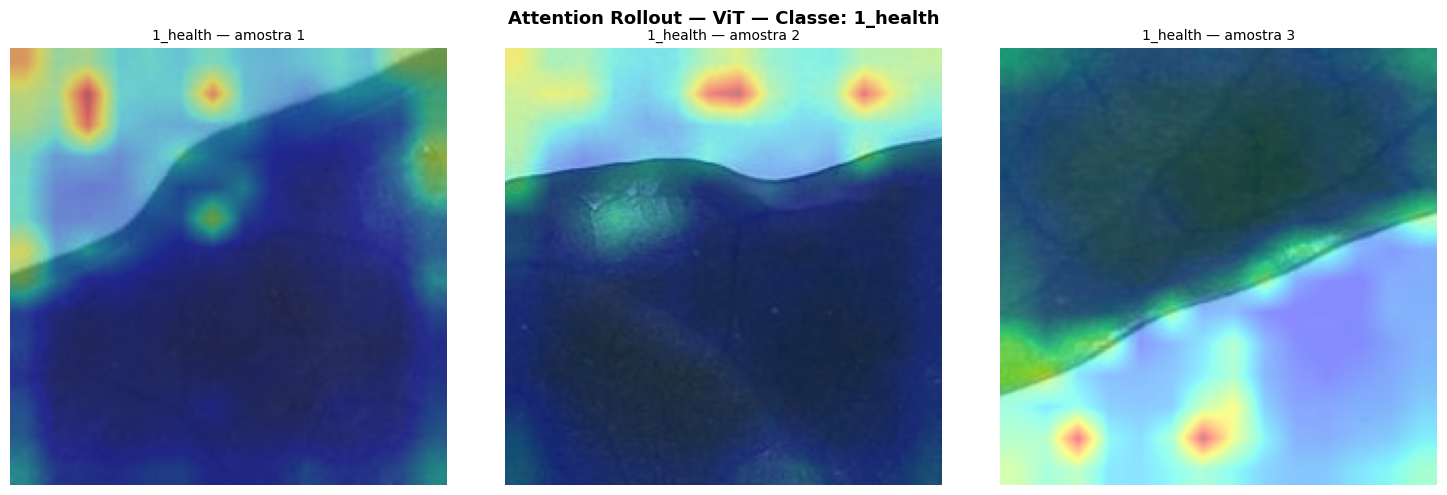

  [1_health] OK


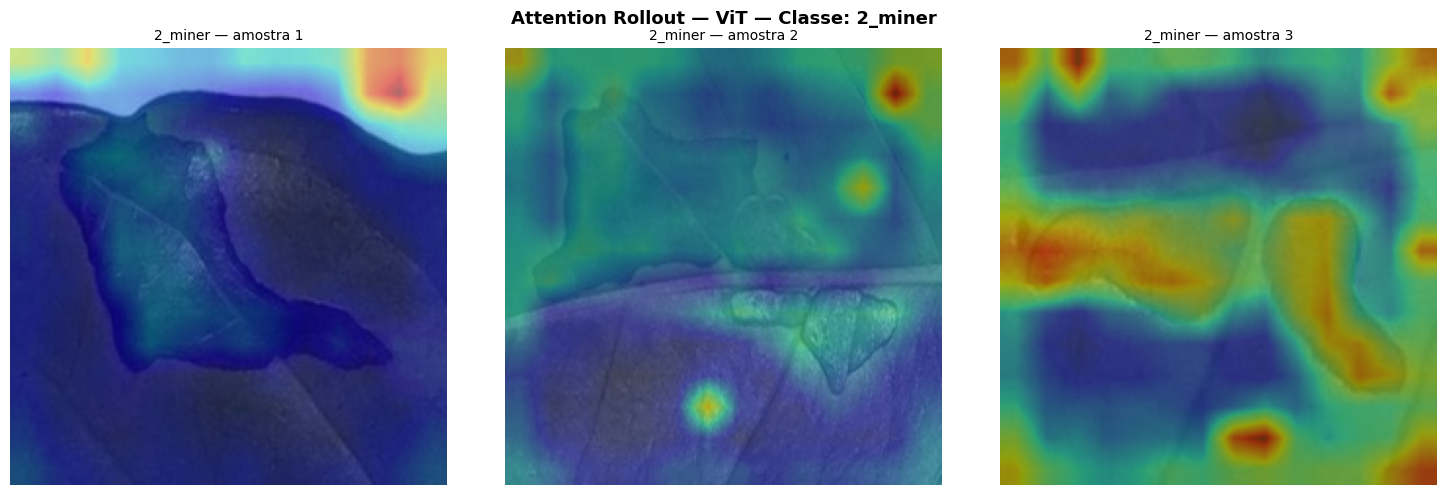

  [2_miner] OK


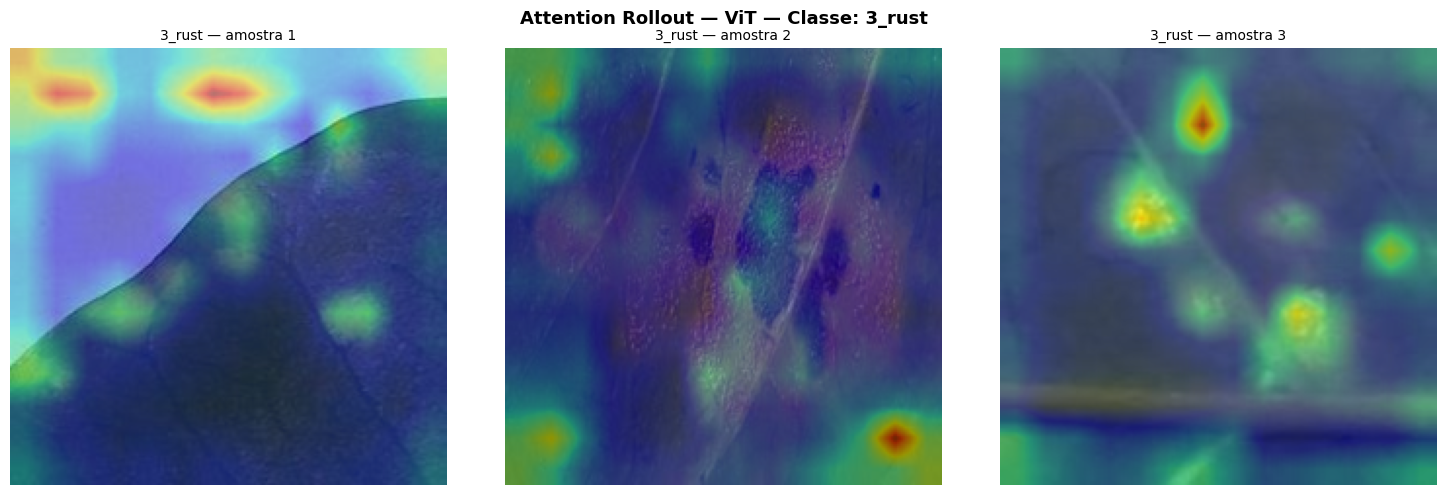

  [3_rust] OK


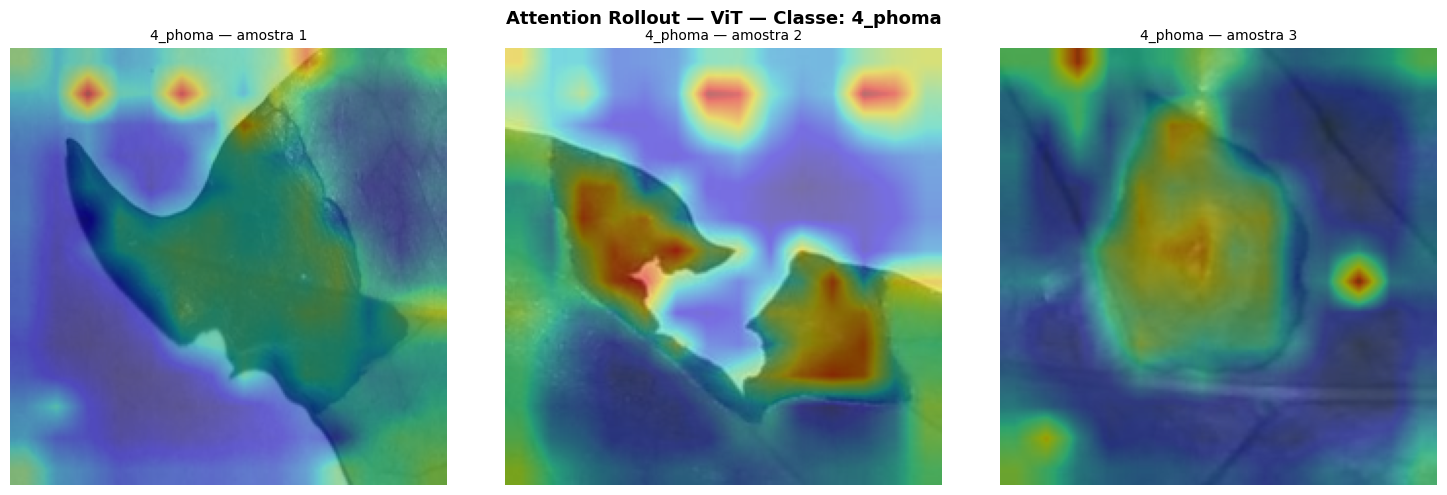

  [4_phoma] OK


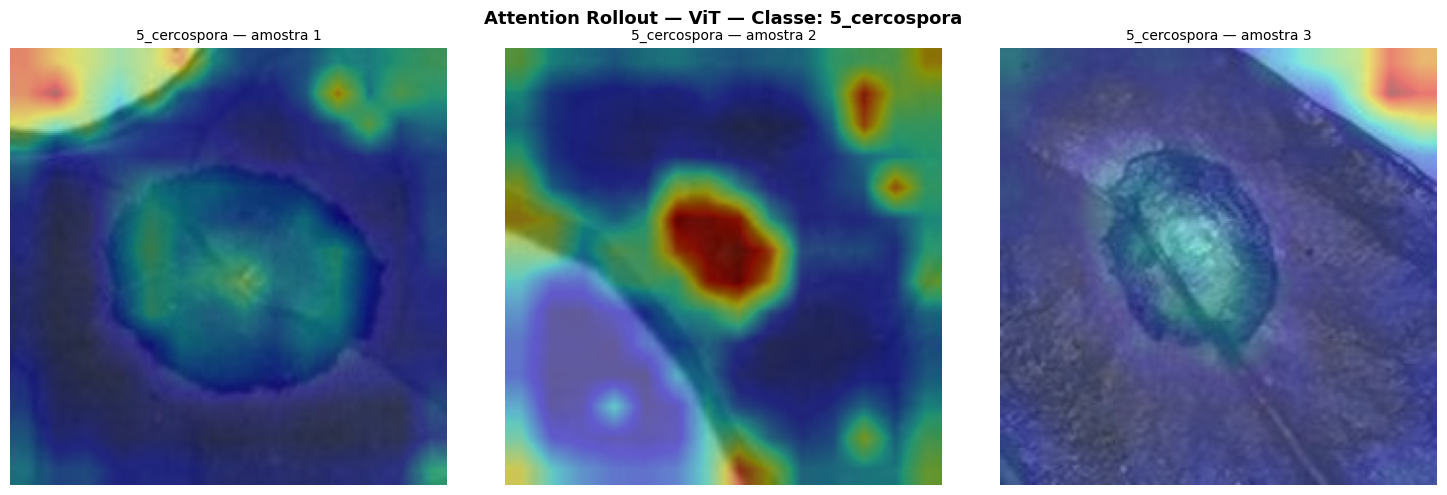

  [5_cercospora] OK


In [11]:
def attention_rollout(model, pixel_values, discard_ratio=0.1, head_fusion="mean"):
    """
    Attention Rollout (Abnar & Zuidema, 2020) — agrega os mapas de atenção de TODAS as
    camadas do ViT num único heatmap, propagando a atenção do token [CLS] até os patches de
    entrada através das conexões residuais. É o equivalente funcional ao Grad-CAM (usado
    nos backbones CNN do mobilenet.ipynb) para arquiteturas baseadas em atenção — o ViT não
    tem mapas de características convolucionais para retropropagar gradientes, então o
    Grad-CAM tradicional simplesmente não se aplica aqui.
    """
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values, output_attentions=True)
    attentions = outputs.attentions  # tupla de (1, n_heads, seq_len, seq_len), uma por camada

    seq_len = attentions[0].size(-1)
    result = torch.eye(seq_len, device=pixel_values.device)

    for attention in attentions:
        if head_fusion == "mean":
            fused = attention.mean(dim=1)[0]
        elif head_fusion == "max":
            fused = attention.max(dim=1)[0][0]
        else:
            fused = attention.min(dim=1)[0][0]

        # Descarta os "discard_ratio" tokens de menor atenção por camada, reduzindo o ruído
        # de fundo que o rollout tende a acumular (prática comum na literatura de Attention
        # Rollout).
        if discard_ratio > 0:
            flat = fused.view(-1)
            n_descartar = int(flat.size(0) * discard_ratio)
            if n_descartar > 0:
                _, idx = flat.topk(n_descartar, largest=False)
                flat[idx] = 0
            fused = flat.view(fused.size())

        identidade = torch.eye(seq_len, device=pixel_values.device)
        a = (fused + identidade) / 2
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result

    # Atenção do token [CLS] (índice 0) para cada patch (índices 1..N)
    mask = result[0, 1:].cpu().numpy()
    grid_size = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(grid_size, grid_size)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask


def gerar_overlay_attention(img_rgb, mask, alpha=0.45):
    """Sobrepõe o heatmap do Attention Rollout à imagem original — mesmo estilo visual do
    Grad-CAM do mobilenet.ipynb, via PIL/matplotlib para não adicionar a dependência do
    OpenCV neste notebook."""
    h, w = img_rgb.shape[:2]
    mask_img = Image.fromarray(np.uint8(255 * mask)).resize((w, h), Image.BILINEAR)
    mask_resized = np.array(mask_img).astype(np.float32) / 255.0
    jet_colors = plt.colormaps.get_cmap("jet")(np.arange(256))[:, :3]
    heat_rgb = jet_colors[np.uint8(255 * mask_resized)]
    overlay = heat_rgb * alpha + img_rgb.astype(np.float32) / 255 * (1 - alpha)
    return np.clip(overlay, 0, 1)


# val_transforms já é determinístico (Resize, sem RandomResizedCrop — ver correção na
# célula de pré-processamento), então é reaproveitado diretamente aqui: a mesma amostra
# sempre gera a mesma visualização de Attention Rollout.
display_transform = val_transforms

N_POR_CLASSE_ATTN = 3
modelo_canonico = ViTForImageClassification.from_pretrained(
    final_training_args.output_dir, attn_implementation="eager"
).to(device)

print("Gerando explicações via Attention Rollout por classe...")
for class_idx, class_name in enumerate(class_names):
    indices_acerto = [i for i in range(len(y_true)) if y_true[i] == class_idx and y_pred[i] == class_idx]
    amostras = indices_acerto[:N_POR_CLASSE_ATTN]
    if not amostras:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 5))
    if len(amostras) == 1:
        axes = [axes]

    for col, idx in enumerate(amostras):
        img_pil = dataset['test'][idx]['image'].convert("RGB")
        pixel_values = display_transform(img_pil).unsqueeze(0).to(device)
        img_rgb = np.array(img_pil.resize((size, size)))

        mask = attention_rollout(modelo_canonico, pixel_values)
        overlay = gerar_overlay_attention(img_rgb, mask)

        axes[col].imshow(overlay)
        axes[col].set_title(f"{class_name} — amostra {col + 1}", fontsize=10)
        axes[col].axis('off')

    plt.suptitle(f'Attention Rollout — ViT — Classe: {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'attention_rollout_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  [{class_name}] OK")

# Avaliação Quantitativa do Attention Rollout (Insertion/Deletion AUC)

In [ ]:
from PIL import ImageFilter

# Mesma métrica objetiva usada no mobilenet.ipynb para o Grad-CAM (Petsiuk, Das & Saenko,
# 2018 — RISE), agora adaptada ao Attention Rollout: mede se o heatmap aponta para as
# regiões que o ViT REALMENTE usa na decisão, complementando a inspeção visual (subjetiva).
# Diferença de implementação: o ViT não embute a normalização como o Keras faz via
# preprocess_input, então cada frame revelado/apagado precisa ser normalizado manualmente
# (mean/std do image_processor) antes de entrar no modelo.
N_FIDELIDADE_POR_CLASSE_VIT = 3
BLUR_RADIUS_VIT = 10
BATCH_FIDELIDADE = 32

mean_arr = np.array(image_processor.image_mean, dtype=np.float32).reshape(3, 1, 1)
std_arr  = np.array(image_processor.image_std,  dtype=np.float32).reshape(3, 1, 1)
_trapz = getattr(np, 'trapezoid', np.trapz)

def curva_insercao_delecao_vit(model, img_rgb, heatmap, class_idx, modo, blur_radius=BLUR_RADIUS_VIT):
    """
    Revela ('insertion') ou apaga ('deletion') progressivamente os blocos da imagem,
    ordenados pela importância do Attention Rollout (do mais para o menos importante), e
    mede como a probabilidade da classe predita reage a cada passo — mesma lógica da versão
    usada no mobilenet.ipynb para o Grad-CAM, só que operando em RGB bruto (0-255) e
    normalizando cada frame manualmente antes de alimentar o ViT.
    """
    H, W = img_rgb.shape[:2]
    hh, hw = heatmap.shape
    ordem = np.argsort(heatmap.flatten())[::-1]
    bh, bw = H // hh, W // hw

    blur_img = np.array(Image.fromarray(img_rgb.astype(np.uint8)).filter(ImageFilter.GaussianBlur(blur_radius)))
    base  = blur_img if modo == 'insertion' else img_rgb
    fonte = img_rgb if modo == 'insertion' else blur_img

    frames = [base.astype(np.float32).copy()]
    atual = base.astype(np.float32).copy()
    for idx in ordem:
        r, c = divmod(int(idx), hw)
        y0, y1 = r * bh, min((r + 1) * bh, H)
        x0, x1 = c * bw, min((c + 1) * bw, W)
        atual = atual.copy()
        atual[y0:y1, x0:x1] = fonte[y0:y1, x0:x1]
        frames.append(atual)

    batch_rgb  = np.stack(frames, axis=0) / 255.0
    batch_chw  = batch_rgb.transpose(0, 3, 1, 2)
    batch_norm = (batch_chw - mean_arr) / std_arr
    batch_tensor = torch.tensor(batch_norm, dtype=torch.float32)

    probs_list = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(batch_tensor), BATCH_FIDELIDADE):
            lote = batch_tensor[i:i + BATCH_FIDELIDADE].to(device)
            logits_b = model(lote).logits
            probs_b = torch.softmax(logits_b, dim=1)[:, class_idx]
            probs_list.append(probs_b.cpu().numpy())
    probs = np.concatenate(probs_list)

    fracoes = np.linspace(0, 1, len(probs))
    auc_val = float(_trapz(probs, fracoes))
    return fracoes, probs, auc_val


print("Avaliando fidelidade do Attention Rollout via Insertion/Deletion AUC (pode demorar alguns minutos)...")
registros_fidelidade_vit = []
for class_idx, class_name in enumerate(class_names):
    indices_acerto = [i for i in range(len(y_true)) if y_true[i] == class_idx and y_pred[i] == class_idx]
    for idx in indices_acerto[:N_FIDELIDADE_POR_CLASSE_VIT]:
        img_pil = dataset['test'][idx]['image'].convert("RGB")
        img_rgb = np.array(img_pil.resize((size, size)))
        pixel_values = display_transform(img_pil).unsqueeze(0).to(device)
        heatmap = attention_rollout(modelo_canonico, pixel_values)

        _, _, auc_ins = curva_insercao_delecao_vit(modelo_canonico, img_rgb, heatmap, class_idx, modo='insertion')
        _, _, auc_del = curva_insercao_delecao_vit(modelo_canonico, img_rgb, heatmap, class_idx, modo='deletion')

        registros_fidelidade_vit.append({
            'classe':           class_name,
            'indice_teste':     idx,
            'insertion_auc':    auc_ins,
            'deletion_auc':     auc_del,
            'score_fidelidade': auc_ins - auc_del,
        })

df_fidelidade_vit = pd.DataFrame(registros_fidelidade_vit)
print("── Fidelidade do Attention Rollout por amostra ──")
print(df_fidelidade_vit.to_string(index=False))

resumo_fidelidade_vit = df_fidelidade_vit.groupby('classe')[['insertion_auc', 'deletion_auc', 'score_fidelidade']].mean()
print("── Fidelidade média por classe ──")
print(resumo_fidelidade_vit.to_string())

print(f"── Fidelidade média geral ({len(df_fidelidade_vit)} amostras) ──")
print(f"  Insertion AUC  : {df_fidelidade_vit['insertion_auc'].mean():.4f} (quanto maior, melhor)")
print(f"  Deletion AUC   : {df_fidelidade_vit['deletion_auc'].mean():.4f} (quanto menor, melhor)")
print(f"  Score (Ins-Del): {df_fidelidade_vit['score_fidelidade'].mean():.4f}")

fidelidade_path_vit = os.path.join(OUTPUT_DIR, f'attention_rollout_fidelidade_{NOME_ARQUIVO}.csv')
df_fidelidade_vit.to_csv(fidelidade_path_vit, index=False)
print(f"Resultados salvos em: {fidelidade_path_vit}")

# XAI — LIME (Explicabilidade por Superpixels)

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn_lime_vit(images):
    """
    Wrapper de predição para o LIME, adaptado ao ViT (PyTorch/HF). O LIME passa um lote de
    imagens RGB uint8 (H, W, 3) -- cada uma é convertida para PIL, normalizada com o mesmo
    val_transforms usado na avaliação (determinístico, sem augmentation aleatória), e
    passada pelo modelo canônico (seed=42, já carregado como modelo_canonico).
    """
    batch = torch.stack([
        val_transforms(Image.fromarray(img.astype(np.uint8)).convert("RGB")) for img in images
    ]).to(device)
    modelo_canonico.eval()
    with torch.no_grad():
        logits_b = modelo_canonico(batch).logits
        probs_b = torch.softmax(logits_b, dim=1)
    return probs_b.cpu().numpy()


explainer_lime_vit = lime_image.LimeImageExplainer(random_state=SEED)
N_LIME_SAMPLES = 1000  # perturbações por explicação (mais = mais preciso, mais lento)

print("Gerando explicações LIME por classe (pode demorar alguns minutos)...")
for class_idx, class_name in enumerate(class_names):
    indices_acerto = [i for i in range(len(y_true)) if y_true[i] == class_idx and y_pred[i] == class_idx]
    if not indices_acerto:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_pil = dataset['test'][indices_acerto[0]]['image'].convert("RGB").resize((size, size))
    img_rgb = np.array(img_pil)

    explanation = explainer_lime_vit.explain_instance(
        img_rgb,
        predict_fn_lime_vit,
        top_labels=1,
        hide_color=0,
        num_samples=N_LIME_SAMPLES,
        random_seed=SEED,
    )

    # Regiões que contribuem positivamente para a classe predita
    temp_pos, mask_pos = explanation.get_image_and_mask(
        class_idx, positive_only=True, num_features=6, hide_rest=False
    )
    # Regiões positivas E negativas (visão completa)
    temp_all, mask_all = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(mark_boundaries(temp_pos.astype(np.float32) / 255, mask_pos))
    axes[1].set_title('LIME — Regiões positivas\n(verde = favor da classe)', fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(mark_boundaries(temp_all.astype(np.float32) / 255, mask_all))
    axes[2].set_title('LIME — Positivo + Negativo\n(verde = favor | vermelho = contra)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Explicação LIME — ViT/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'lime_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  [{class_name}] OK")

# XAI — Integrated Gradients (Feature Attribution)

In [ ]:
def integrated_gradients_vit(model, pixel_values, class_idx, m_steps=50, batch_size=16):
    """
    Integrated Gradients (Sundararajan et al., 2017) adaptado ao ViT (PyTorch/autograd) --
    equivalente funcional à versão em tf.GradientTape do mobilenet.ipynb. Baseline: imagem
    preta (zeros) no MESMO espaço já normalizado de pixel_values.
    """
    baseline = torch.zeros_like(pixel_values)
    alphas = torch.linspace(0.0, 1.0, m_steps + 1, device=pixel_values.device)

    interp = torch.cat([baseline + a * (pixel_values - baseline) for a in alphas], dim=0)

    all_grads = []
    model.eval()
    for i in range(0, len(interp), batch_size):
        batch = interp[i:i + batch_size].clone().detach().requires_grad_(True)
        logits_b = model(batch).logits
        target = logits_b[:, class_idx].sum()
        grad_b, = torch.autograd.grad(target, batch)
        all_grads.append(grad_b.detach())

    grads = torch.cat(all_grads, dim=0)
    avg_grads = ((grads[:-1] + grads[1:]) / 2.0).mean(dim=0, keepdim=True)

    # IG = (img − baseline) × gradiente médio
    ig = (pixel_values - baseline) * avg_grads
    return ig[0].permute(1, 2, 0).cpu().numpy()   # (size, size, 3)


print("Gerando explicações por Integrated Gradients por classe...")
for class_idx, class_name in enumerate(class_names):
    indices_acerto = [i for i in range(len(y_true)) if y_true[i] == class_idx and y_pred[i] == class_idx]
    if not indices_acerto:
        print(f"  [{class_name}] Sem acertos — pulando.")
        continue

    img_pil = dataset['test'][indices_acerto[0]]['image'].convert("RGB")
    img_rgb = np.array(img_pil.resize((size, size)))
    pixel_values = display_transform(img_pil).unsqueeze(0).to(device)

    ig = integrated_gradients_vit(modelo_canonico, pixel_values, class_idx)

    # Mapa de importância absoluta (média dos canais RGB)
    ig_abs  = np.abs(ig).mean(axis=-1)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)

    # Mapa de contribuição signed (positivo = favor, negativo = contra)
    ig_signed      = ig.mean(axis=-1)
    ig_signed_norm = (ig_signed - ig_signed.min()) / (ig_signed.max() - ig_signed.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original\n{class_name}', fontsize=10)
    axes[0].axis('off')

    im1 = axes[1].imshow(ig_norm, cmap='hot')
    axes[1].set_title('IG — Importância absoluta\n(mais quente = mais relevante)', fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    cmap_rdb = plt.colormaps.get_cmap('RdBu_r')
    ig_rgb   = cmap_rdb(ig_signed_norm)[:, :, :3]
    overlay  = ig_rgb * 0.5 + img_rgb.astype(np.float32) / 255 * 0.5
    axes[2].imshow(np.clip(overlay, 0, 1))
    axes[2].set_title('IG — Overlay (azul = contra | vermelho = favor)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle(f'Integrated Gradients — ViT/{DATASET_ATIVO} — {class_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'ig_{NOME_ARQUIVO}_{class_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  [{class_name}] OK")

Latência (Modelo Canônico, seed=42)

In [12]:
# Benchmark "cru" (forward pass direto, sem o wrapper pipeline()) — a mesma metodologia
# usada no mobilenet.ipynb para o modelo Keras em memória (warmup + 100 execuções + média/
# desvio-padrão/p95), para que a comparação de latência entre ViT e as CNNs seja justa. O
# pipeline() embutia pré/pós-processamento e overhead do Python que não é comparável ao
# benchmark "puro" do outro notebook.
final_model_path = final_training_args.output_dir
model_eager = final_trainer.model.to(device)
model_eager.eval()

N_WARMUP = 10
N_RUNS   = 100

sample_pixel_values = display_transform(sample_image_for_latency_test.convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    for _ in range(N_WARMUP):
        _ = model_eager(sample_pixel_values)

tempos = []
with torch.no_grad():
    for _ in range(N_RUNS):
        if device.type == "cuda":
            torch.cuda.synchronize()  # CUDA é assíncrono — sem isso, mediríamos só o tempo de "disparo" do kernel
        t0 = time.perf_counter()
        _ = model_eager(sample_pixel_values)
        if device.type == "cuda":
            torch.cuda.synchronize()
        tempos.append((time.perf_counter() - t0) * 1000)

latencia_media = np.mean(tempos)
latencia_std   = np.std(tempos)
latencia_p95   = np.percentile(tempos, 95)

print(f"── Benchmark de Inferência (PyTorch Eager, {device.type.upper()}, modelo canônico seed=42) ──")
print(f"  Latência média  : {latencia_media:.2f} ms")
print(f"  Desvio padrão   : {latencia_std:.2f} ms")
print(f"  Percentil 95    : {latencia_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / latencia_media:.1f} imagens/s")

── Benchmark de Inferência (PyTorch Eager, CUDA, modelo canônico seed=42) ──
  Latência média  : 8.03 ms
  Desvio padrão   : 0.72 ms
  Percentil 95    : 9.52 ms
  FPS equivalente : 124.5 imagens/s


Exportando modelo (PyTorch Mobile, Modelo Canônico)

In [13]:
try:
    export_model = ViTForImageClassification.from_pretrained(final_model_path)
    export_model.eval()

    # Quantização dinâmica INT8 das camadas Linear — a maioria dos parâmetros de um
    # Transformer está nas projeções lineares (Q/K/V, saída da atenção e MLP). É o
    # equivalente funcional ao tf.lite.Optimize.DEFAULT usado no mobilenet.ipynb, que
    # quantiza o MobileNetV2 de 32 para 8 bits. A quantização dinâmica só roda em CPU
    # (não há kernel CUDA para ela), o que já é compatível com export_model acima (carregado
    # sem .to(device)) e com o cenário real de inferência offline no celular.
    export_model_quant = torch.quantization.quantize_dynamic(
        export_model, {torch.nn.Linear}, dtype=torch.qint8
    )

    class ViTWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            return self.model(x).logits

    wrapper_model = ViTWrapper(export_model_quant)
    wrapper_model.eval()

    example_input = torch.randn(1, 3, 224, 224)
    traced_model = torch.jit.trace(wrapper_model, example_input)

    from torch.utils.mobile_optimizer import optimize_for_mobile
    optimized_model = optimize_for_mobile(traced_model)

    ptl_path = os.path.join(final_model_path, f"{NOME_ARQUIVO}.ptl")
    optimized_model._save_for_lite_interpreter(ptl_path)
    print(f"✅ Modelo PyTorch Mobile (quantizado INT8 dinâmico) salvo com sucesso em: {ptl_path}")

except Exception as e:
    print(f"❌ Erro ao converter para PyTorch Mobile: {e}")

/tmp/ipykernel_58/4253653676.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  export_model_quant = torch.quantization.quantize_dynamic(
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:4713: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  war

✅ Modelo PyTorch Mobile (quantizado INT8 dinâmico) salvo com sucesso em: outputs/ViT_newdataset/vit_seed42/ViT_newdataset.ptl


/tmp/ipykernel_58/4253653676.py:32: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model._save_for_lite_interpreter(ptl_path)


# Latência (Modelo Exportado — PyTorch Mobile, CPU)

In [14]:
# Benchmarka o modelo REALMENTE exportado (.ptl, já com quantização dinâmica INT8), do
# mesmo jeito que o mobilenet.ipynb faz com o TFLite: carrega o artefato do disco e mede em
# CPU (o cenário real de inferência offline no celular), separado do benchmark "Eager"
# acima (que roda em GPU, se disponível, e SEM quantização).
from torch.jit.mobile import _load_for_lite_interpreter

mobile_model = _load_for_lite_interpreter(ptl_path)
input_ptl = sample_pixel_values.detach().cpu()

for _ in range(N_WARMUP):
    _ = mobile_model(input_ptl)

tempos_mobile = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _ = mobile_model(input_ptl)
    tempos_mobile.append((time.perf_counter() - t0) * 1000)

lat_mobile_media = np.mean(tempos_mobile)
lat_mobile_std   = np.std(tempos_mobile)
lat_mobile_p95   = np.percentile(tempos_mobile, 95)
ptl_size_mb      = os.path.getsize(ptl_path) / (1024 ** 2)

print("── Benchmark de Inferência (PyTorch Mobile / .ptl quantizado INT8, CPU) ──")
print(f"  Latência média  : {lat_mobile_media:.2f} ms")
print(f"  Desvio padrão   : {lat_mobile_std:.2f} ms")
print(f"  Percentil 95    : {lat_mobile_p95:.2f} ms")
print(f"  FPS equivalente : {1000 / lat_mobile_media:.1f} imagens/s")
print(f"  Tamanho do modelo (.ptl, quantizado): {ptl_size_mb:.2f} MB")
print(f"\nNota: a comparação com a latência 'Eager' acima não é 1:1 — aquele benchmark roda em "
      f"{device.type.upper()} sem quantização, enquanto este (.ptl) é sempre avaliado em CPU "
      f"com pesos INT8, simulando o cenário real de inferência offline no celular (o mesmo "
      f"motivo pelo qual o mobilenet.ipynb reporta Keras e TFLite separadamente, em vez de um "
      f"único número).")

── Benchmark de Inferência (PyTorch Mobile / .ptl quantizado INT8, CPU) ──
  Latência média  : 80.75 ms
  Desvio padrão   : 13.13 ms
  Percentil 95    : 100.63 ms
  FPS equivalente : 12.4 imagens/s
  Tamanho do modelo (.ptl, quantizado): 42.26 MB

Nota: a comparação com a latência 'Eager' acima não é 1:1 — aquele benchmark roda em CUDA sem quantização, enquanto este (.ptl) é sempre avaliado em CPU com pesos INT8, simulando o cenário real de inferência offline no celular (o mesmo motivo pelo qual o mobilenet.ipynb reporta Keras e TFLite separadamente, em vez de um único número).


# Linha-Resumo para a Tabela Comparativa (Modelos x Datasets)

In [15]:
# Constroi uma linha-resumo no MESMO formato/nomes de coluna usados pelo resultados_comparativos
# do mobilenet.ipynb (Modelo, Dataset, medias/desvios multi-seed, N_seeds, latencia em
# memoria/exportado, tamanho exportado) para que as duas tabelas sejam concatenaveis com um
# simples pd.concat, formando a matriz Dataset x Modelo completa (CNNs + ViT).
resultados_comparativos_vit = [{
    'Modelo':                    MODELO_NOME,
    'Dataset':                   DATASET_ATIVO,
    'Acurácia (méd)':            round(media_multiseed['accuracy'], 4),
    'Acurácia (dp)':             round(desvio_multiseed['accuracy'], 4),
    'F1-Macro (méd)':            round(media_multiseed['f1_macro'], 4),
    'F1-Macro (dp)':             round(desvio_multiseed['f1_macro'], 4),
    'Precision-Macro (méd)':     round(media_multiseed['precision_macro'], 4),
    'Recall-Macro (méd)':        round(media_multiseed['recall_macro'], 4),
    'N_seeds':                   len(df_multiseed),
    'Lat. Em Memória (ms)':      round(latencia_media, 2),
    'Lat. Exportado (ms)':       round(lat_mobile_media, 2),
    'Tamanho Exportado (MB)':    round(ptl_size_mb, 2),
    'Formato Exportado':         'PyTorch Mobile INT8 (.ptl)',
}]

df_comparativo_vit = pd.DataFrame(resultados_comparativos_vit)
print("=" * 90)
print("  LINHA COMPARATIVA — ViT")
print("=" * 90)
print(df_comparativo_vit.to_string(index=False))
print("=" * 90)

comparativo_path = os.path.join(OUTPUT_DIR, f'resultados_comparativos_{NOME_ARQUIVO}.csv')
df_comparativo_vit.to_csv(comparativo_path, index=False)
print(f"Linha salva em: {comparativo_path}")
print("Copie a pasta 'outputs/' para o mesmo diretório do mobilenet.ipynb. Os nomes de coluna")
print("são IDÊNTICOS aos de resultados_comparativos do mobilenet.ipynb, de propósito — basta")
print("pd.concat([df_comp, df_comparativo_vit], ignore_index=True) para juntar as duas tabelas")
print("numa única matriz Dataset × Modelo (CNNs + ViT).")

  LINHA COMPARATIVA — ViT
Modelo    Dataset  Acurácia (méd)  Acurácia (dp)  F1-Macro (méd)  F1-Macro (dp)  Precision-Macro (méd)  Recall-Macro (méd)  N_seeds  Lat. Em Memória (ms)  Lat. Exportado (ms)  Tamanho Exportado (MB)          Formato Exportado
   ViT newdataset          0.9682         0.0024           0.966         0.0028                 0.9651              0.9672        3                  8.03                80.75                   42.26 PyTorch Mobile INT8 (.ptl)
Linha salva em: outputs/ViT_newdataset/resultados_comparativos_ViT_newdataset.csv
Copie a pasta 'outputs/' para o mesmo diretório do mobilenet.ipynb. Os nomes de coluna
são IDÊNTICOS aos de resultados_comparativos do mobilenet.ipynb, de propósito — basta
pd.concat([df_comp, df_comparativo_vit], ignore_index=True) para juntar as duas tabelas
numa única matriz Dataset × Modelo (CNNs + ViT).
